In [18]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [19]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

df["hour"] = df["hour"].astype(int) % 24
df["day_of_week"] = df["day_of_week"].astype(int) % 7
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

In [20]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']
zone_cols = [
    "zone_residential",
    "zone_commercial",
    "zone_industrial"
]

In [21]:
SEQ_LEN = 24

class DatasetRQ7(Dataset):
    def __init__(self, df):
        self.Xl = df[load_features].values.astype(np.float32)
        self.Xt = df[temp_features].values.astype(np.float32)
        self.Xc = df[calendar_features].values.astype(np.int64)
        self.y = df[zone_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.Xl) - SEQ_LEN

    def __getitem__(self, idx):
        return (
            torch.tensor(self.Xl[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xt[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xc[idx:idx+SEQ_LEN]),
            torch.tensor(self.y[idx+SEQ_LEN])
        )

from sklearn.preprocessing import MinMaxScaler

# ==========================================
# CHRONOLOGICAL TRAIN-TEST SPLIT
# ==========================================

split_idx = int(0.8 * len(df))

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# ==========================================
# NORMALIZATION
# ==========================================

scaler = MinMaxScaler()

scale_cols = (
    load_features +
    temp_features +
    zone_cols
)

train_df[scale_cols] = scaler.fit_transform(
    train_df[scale_cols]
)

test_df[scale_cols] = scaler.transform(
    test_df[scale_cols]
)

# ==========================================
# DATASETS
# ==========================================

train_ds = DatasetRQ7(train_df)
test_ds = DatasetRQ7(test_df)

# ==========================================
# DATALOADERS
# ==========================================

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

In [22]:
class AdaptiveFusionBaseline(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=len(load_features),
            hidden_size=64,
            batch_first=True
        )

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        self.total_dim = 64 + 32 + 18

        # Adaptive attention
        self.attention = nn.Sequential(
            nn.Linear(self.total_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

        # Shared representation
        self.shared_representation = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        # Dependency learning
        self.interaction_layer = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )

        # Deterministic output
        self.output_head = nn.Linear(64,len(zone_cols))

    def forward(self, Xl, Xt, Xc):

        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        cal_out = torch.cat([

            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])

        ], dim=1)

        load_out = F.layer_norm(load_out, load_out.shape[1:])
        temp_out = F.layer_norm(temp_out, temp_out.shape[1:])
        cal_out = F.layer_norm(cal_out, cal_out.shape[1:])

        combined = torch.cat([
            load_out,
            temp_out,
            cal_out
        ], dim=1)

        logits = self.attention(combined)

        weights = torch.softmax(
            logits / 1.5,
            dim=1
        )

        w_load = weights[:, 0].unsqueeze(1)
        w_temp = weights[:, 1].unsqueeze(1)
        w_cal = weights[:, 2].unsqueeze(1)

        fused = torch.cat([

            load_out * w_load,
            temp_out * w_temp,
            cal_out * w_cal

        ], dim=1)

        fused = fused + combined

        shared_features = self.shared_representation(fused)

        interaction_features = self.interaction_layer(
            shared_features
        )

        out = self.output_head(interaction_features)

        return out, weights

In [23]:
class AdaptiveFusionQuantileModel(nn.Module):

    def __init__(self, quantiles):
        super().__init__()

        self.quantiles = quantiles

        self.lstm = nn.LSTM(
            input_size=len(load_features),
            hidden_size=64,
            batch_first=True
        )

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        self.total_dim = 64 + 32 + 18

        self.attention = nn.Sequential(
            nn.Linear(self.total_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

        self.shared_representation = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        self.interaction_layer = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )

        # QUANTILE OUTPUTS
        self.output_head = nn.Sequential(

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(
                64,
                len(zone_cols) * len(quantiles)
            ))                           

    def forward(self, Xl, Xt, Xc):

        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        cal_out = torch.cat([

            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])

        ], dim=1)

        load_out = F.layer_norm(load_out, load_out.shape[1:])
        temp_out = F.layer_norm(temp_out, temp_out.shape[1:])
        cal_out = F.layer_norm(cal_out, cal_out.shape[1:])

        combined = torch.cat([
            load_out,
            temp_out,
            cal_out
        ], dim=1)

        logits = self.attention(combined)

        weights = torch.softmax(
            logits / 1.5,
            dim=1
        )

        w_load = weights[:, 0].unsqueeze(1)
        w_temp = weights[:, 1].unsqueeze(1)
        w_cal = weights[:, 2].unsqueeze(1)

        fused = torch.cat([

            load_out * w_load,
            temp_out * w_temp,
            cal_out * w_cal

        ], dim=1)

        fused = fused + combined

        shared_features = self.shared_representation(fused)

        interaction_features = self.interaction_layer(
            shared_features
        )

        out = self.output_head(interaction_features)

        out = out.view(
            out.size(0),
            len(zone_cols),
            len(self.quantiles)
        )

        return out

In [24]:
def quantile_loss(preds, target, quantiles):

    loss = 0

    for i, q in enumerate(quantiles):

        # -----------------------------------
        # QUANTILE ERRORS
        # -----------------------------------
        errors = target - preds[:, :, i]

        # -----------------------------------
        # PEAK WEIGHTING
        # Higher weight for high-load periods
        # -----------------------------------
        peak_weight = 1 + 2 * (
            target > 0.8
        ).float()

        # -----------------------------------
        # QUANTILE LOSS
        # -----------------------------------
        q_loss = torch.max(
            (q - 1) * errors,
            q * errors
        )

        # -----------------------------------
        # WEIGHTED LOSS
        # -----------------------------------
        loss += torch.mean(
            peak_weight * q_loss
        )

    return loss

In [25]:
def train_baseline(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(20):
        for Xl, Xt, Xc, y in train_loader:
            Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

            optimizer.zero_grad()
            preds, _ = model(Xl, Xt, Xc)

            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

In [26]:
def train_quantile(model, quantiles):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(20):
        for Xl, Xt, Xc, y in train_loader:
            Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

            optimizer.zero_grad()
            preds = model(Xl, Xt, Xc)

            loss = quantile_loss(preds, y, quantiles)
            loss.backward()
            optimizer.step()

In [27]:
quantiles = [0.1, 0.5, 0.9]

baseline_model = AdaptiveFusionBaseline().to(device)

quantile_model = AdaptiveFusionQuantileModel(
    quantiles
).to(device)

train_baseline(baseline_model)
train_quantile(quantile_model, quantiles)

In [28]:
def evaluate_models():
    
    baseline_model.eval()
    quantile_model.eval()
    
    baseline_preds, p50, p90, actual = [], [], [], []

    with torch.no_grad():
        for Xl, Xt, Xc, y in test_loader:
            Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

            b, _ = baseline_model(Xl, Xt, Xc)
            b = b.cpu().numpy()
            q = quantile_model(Xl, Xt, Xc).cpu().numpy()

            baseline_preds.append(b)
            p50.append(q[:, :, 1])

            p90.append(q[:, :, 2])

            actual.append(y.numpy())

    baseline_preds = np.vstack(baseline_preds)

    p50 = np.vstack(p50)

    p90 = np.vstack(p90)

    actual = np.vstack(actual)

    return baseline_preds, p50, p90, actual

baseline_preds, p50, p90, actual = evaluate_models()

actual_total = actual.sum(axis=1)

baseline_total = baseline_preds.sum(axis=1)

p50_total = p50.sum(axis=1)

p90_total = p90.sum(axis=1)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

forecast_results = pd.DataFrame({

    "Model": ["Baseline", "P50"],

    "MAE": [

        mean_absolute_error(actual.flatten(),baseline_preds.flatten()),

        mean_absolute_error(actual.flatten(),p50.flatten())

    ],

    "RMSE": [

        np.sqrt(mean_squared_error(actual.flatten(),baseline_preds.flatten())),
        
        np.sqrt(mean_squared_error(actual.flatten(),p50.flatten()))

    ]

})

forecast_results.to_csv(
    "outputs/tables/rq7_forecast_results.csv",
    index=False
)

forecast_results

,Model,MAE,RMSE
0,Baseline,0.022183,0.029922
1,P50,0.019632,0.026508


In [29]:
threshold = np.percentile(
    actual_total,
    95
)

actual_peaks = actual_total > threshold

alerts_quantile = p90_total > threshold

alerts_baseline = baseline_total > threshold

In [30]:
alert_results = pd.DataFrame({
    "Model": ["Baseline", "Adaptive + Quantile"],
    "Precision": [
        precision_score(actual_peaks, alerts_baseline),
        precision_score(actual_peaks, alerts_quantile)
    ],
    "Recall": [
        recall_score(actual_peaks, alerts_baseline),
        recall_score(actual_peaks, alerts_quantile)
    ]
})

alert_results.to_csv("outputs/tables/rq7_alert_results.csv", index=False)
alert_results

peak_capture_rate = np.mean(
    actual_total[actual_peaks]
    <=
    p90_total[actual_peaks]
)

print("Peak Capture Rate:", peak_capture_rate)

Peak Capture Rate: 0.9961832061068703


In [31]:
planning_results = pd.DataFrame({
    "Strategy": ["Baseline", "Uncertainty-aware (P90)"],
    "Underestimation": [
    np.mean(baseline_total < actual_total),
    np.mean(p90_total < actual_total)],
    "Overestimation": [
    np.mean(baseline_total > actual_total),
    np.mean(p90_total > actual_total)]
})

planning_results.to_csv("outputs/tables/rq7_planning_results.csv", index=False)
planning_results

,Strategy,Underestimation,Overestimation
0,Baseline,0.508145,0.491855
1,Uncertainty-aware (P90),0.000636,0.999364


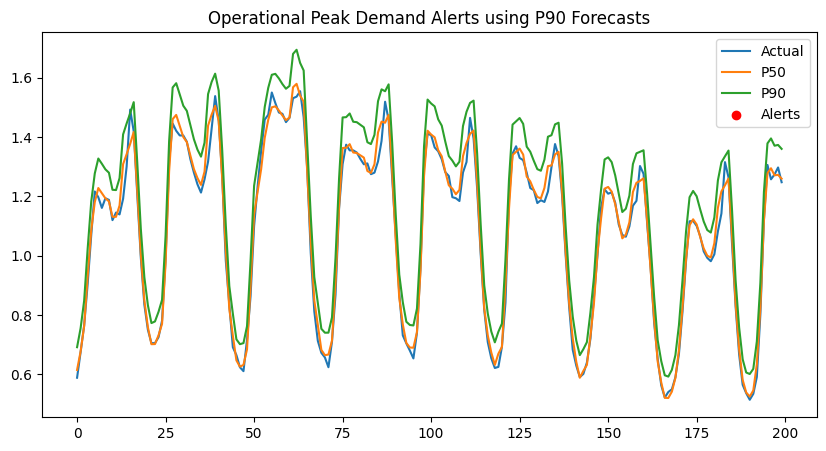

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    actual_total[:200],
    label="Actual"
)

plt.plot(
    p50_total[:200],
    label="P50"
)

plt.plot(
    p90_total[:200],
    label="P90"
)

alerts_idx = np.where(alerts_quantile[:200])[0]
plt.scatter(
    alerts_idx,
    actual_total[:200][alerts_idx],
    color='red',
    label="Alerts"
)

plt.legend()
plt.title("Operational Peak Demand Alerts using P90 Forecasts")

plt.savefig("outputs/figures/rq7_peak_alerts.pdf")

plt.show()

In [33]:
zone_forecast_results = []

for i, zone in enumerate(zone_cols):

    baseline_mae = mean_absolute_error(
        actual[:, i],
        baseline_preds[:, i]
    )

    p50_mae = mean_absolute_error(
        actual[:, i],
        p50[:, i]
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            actual[:, i],
            baseline_preds[:, i]
        )
    )

    p50_rmse = np.sqrt(
        mean_squared_error(
            actual[:, i],
            p50[:, i]
        )
    )

    zone_forecast_results.append({

        "Zone": zone,

        "Baseline_MAE": baseline_mae,
        "P50_MAE": p50_mae,

        "Baseline_RMSE": baseline_rmse,
        "P50_RMSE": p50_rmse

    })

zone_forecast_results = pd.DataFrame(
    zone_forecast_results
)

zone_forecast_results.to_csv(
    "outputs/tables/rq7_zone_forecast_results.csv",
    index=False
)

zone_forecast_results

,Zone,Baseline_MAE,P50_MAE,Baseline_RMSE,P50_RMSE
0,zone_residential,0.017492,0.014932,0.022385,0.019041
1,zone_commercial,0.017645,0.014787,0.024155,0.019152
2,zone_industrial,0.031412,0.029177,0.040017,0.037131


In [34]:
zone_operational_results = []

for i, zone in enumerate(zone_cols):

    threshold = np.percentile(
        actual[:, i],
        95
    )

    actual_peaks = actual[:, i] > threshold

    baseline_peak = baseline_preds[:, i] > threshold

    p90_peak = p90[:, i] > threshold

    peak_capture_rate = np.mean(
        actual[:, i][actual_peaks]
        <=
        p90[:, i][actual_peaks]
    )

    zone_operational_results.append({

        "Zone": zone,

        "Baseline_Underestimation":
            np.mean(
                baseline_preds[:, i]
                <
                actual[:, i]
            ),

        "P90_Underestimation":
            np.mean(
                p90[:, i]
                <
                actual[:, i]
            ),

        "Baseline_Overestimation":
            np.mean(
                baseline_preds[:, i]
                >
                actual[:, i]
            ),

        "P90_Overestimation":
            np.mean(
                p90[:, i]
                >
                actual[:, i]
            ),

        "Baseline_Precision":
            precision_score(
                actual_peaks,
                baseline_peak
            ),

        "P90_Precision":
            precision_score(
                actual_peaks,
                p90_peak
            ),

        "Baseline_Recall":
            recall_score(
                actual_peaks,
                baseline_peak
            ),

        "P90_Recall":
            recall_score(
                actual_peaks,
                p90_peak
            ),

        "Peak_Capture_Rate":
            peak_capture_rate

    })

zone_operational_results = pd.DataFrame(
    zone_operational_results
)

zone_operational_results.to_csv(
    "outputs/tables/rq7_zone_operational_results.csv",
    index=False
)

zone_operational_results

,Zone,Baseline_Underestimation,P90_Underestimation,Baseline_Overestimation,P90_Overestimation,Baseline_Precision,P90_Precision,Baseline_Recall,P90_Recall,Peak_Capture_Rate
0,zone_residential,0.506108,0.040341,0.493892,0.959659,0.752643,0.616000,0.905852,0.979644,0.894402
1,zone_commercial,0.511835,0.128659,0.488165,0.871341,0.714286,0.794652,0.954198,0.945293,0.609415
2,zone_industrial,0.481675,0.079028,0.518325,0.920972,0.665231,0.475858,0.786260,0.952926,0.751908


In [35]:
zone_forecast_results = []

for i, zone in enumerate(zone_cols):

    # =====================================
    # BASELINE METRICS
    # =====================================
    baseline_mae = mean_absolute_error(
        actual[:, i],
        baseline_preds[:, i]
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            actual[:, i],
            baseline_preds[:, i]
        )
    )

    # =====================================
    # P50 METRICS
    # =====================================
    p50_mae = mean_absolute_error(
        actual[:, i],
        p50[:, i]
    )

    p50_rmse = np.sqrt(
        mean_squared_error(
            actual[:, i],
            p50[:, i]
        )
    )

    # =====================================
    # STORE RESULTS
    # =====================================
    zone_forecast_results.append({

        "Zone": zone,

        "Baseline_MAE": baseline_mae,
        "P50_MAE": p50_mae,

        "Baseline_RMSE": baseline_rmse,
        "P50_RMSE": p50_rmse,

        "MAE_Improvement":
            baseline_mae - p50_mae,

        "RMSE_Improvement":
            baseline_rmse - p50_rmse
    })

# =====================================
# DATAFRAME
# =====================================
zone_forecast_results = pd.DataFrame(
    zone_forecast_results
)

# =====================================
# SAVE
# =====================================
zone_forecast_results.to_csv(
    "outputs/tables/rq7_zone_forecast_results.csv",
    index=False
)

# =====================================
# DISPLAY
# =====================================
zone_forecast_results

,Zone,Baseline_MAE,P50_MAE,Baseline_RMSE,P50_RMSE,MAE_Improvement,RMSE_Improvement
0,zone_residential,0.017492,0.014932,0.022385,0.019041,0.002560,0.003344
1,zone_commercial,0.017645,0.014787,0.024155,0.019152,0.002858,0.005004
2,zone_industrial,0.031412,0.029177,0.040017,0.037131,0.002235,0.002886
